# 02 · Graph structure (HI-Small)
Whole-graph statistics use DuckDB + scipy (the graph has ~5M transactions); NetworkX is used
only on subgraphs. Self-loops are excluded from structural measures.

In [1]:
import time

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyvis.network import Network

from aml.config import load_config
from aml.graph import build_aggregated_graph, component_labels, ego_subgraph

cfg = load_config()
FIG, TAB = cfg.root / cfg.paths.figures_dir, cfg.root / cfg.paths.tables_dir
P = cfg.transactions_parquet.as_posix()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
LICIT, ILLICIT = "#4C72B0", "#C44E52"
q = lambda sql: duckdb.sql(sql).df()

def save(fig, name):
    fig.tight_layout(); fig.savefig(FIG / f"{name}.png", bbox_inches="tight"); plt.show()

## Node index and account-pair edges (DuckDB)

In [2]:
duckdb.sql(f"""
CREATE OR REPLACE TABLE nodes AS
  SELECT acc, row_number() OVER (ORDER BY acc) - 1 AS idx
  FROM (SELECT src AS acc FROM '{P}' UNION SELECT dst FROM '{P}')
""")
duckdb.sql(f"""
CREATE OR REPLACE TABLE pairs AS
  SELECT s.idx AS s, d.idx AS d, count(*) AS n, sum(amt_usd) AS usd, sum(is_laundering) AS ill
  FROM '{P}' t JOIN nodes s ON t.src = s.acc JOIN nodes d ON t.dst = d.acc
  WHERE t.src <> t.dst GROUP BY 1, 2
""")
n_nodes = duckdb.sql("SELECT count(*) FROM nodes").fetchone()[0]
pairs = q("SELECT * FROM pairs")
print(f"{n_nodes:,} accounts, {len(pairs):,} directed account pairs (excluding self-loops)")

515,088 accounts, 647,939 directed account pairs (excluding self-loops)


## Degree distributions (log-log)
Degree = distinct counterparties.

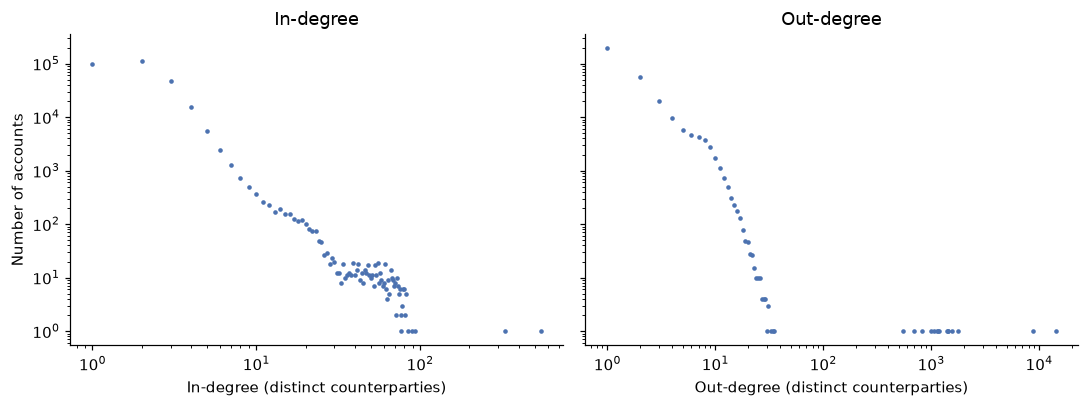

,in_degree,out_degree
count,515088.000000,515088.000000
mean,1.257919,1.257919
std,2.531536,24.201762
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,1.000000
max,545.000000,14230.000000


In [3]:
deg_out = pairs.groupby("s").size().reindex(range(n_nodes), fill_value=0)
deg_in = pairs.groupby("d").size().reindex(range(n_nodes), fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, deg, t in zip(axes, (deg_in, deg_out), ("In-degree", "Out-degree")):
    vc = deg[deg > 0].value_counts().sort_index()
    ax.loglog(vc.index, vc.values, ".", color=LICIT, ms=4)
    ax.set_xlabel(f"{t} (distinct counterparties)"); ax.set_title(t)
axes[0].set_ylabel("Number of accounts")
save(fig, "graph_degree_distributions")
deg_tab = pd.DataFrame({"in_degree": deg_in.describe(), "out_degree": deg_out.describe()})
deg_tab.to_csv(TAB / "graph_degree_summary.csv"); deg_tab

## Strongly and weakly connected components

,n_components,largest,non_trivial (size>1),nodes_in_non_trivial
strong,494769,17075,2928,23247
weak,114139,372089,21785,422734


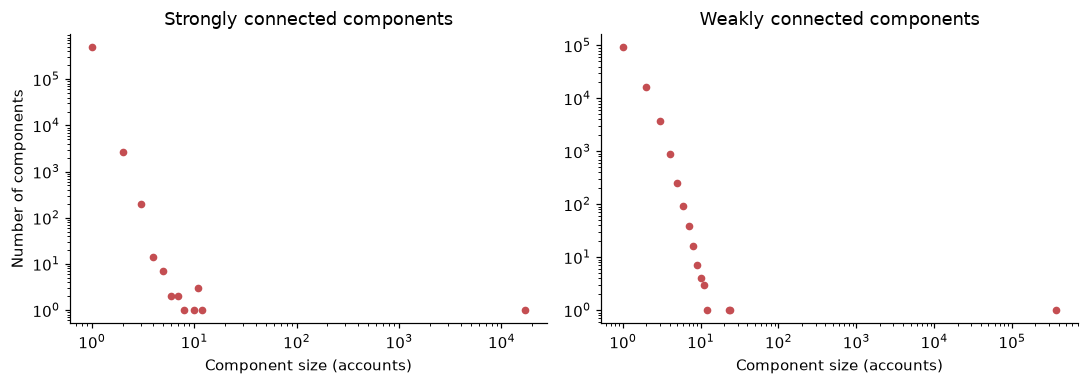

In [4]:
scc, wcc = component_labels(pairs.s.to_numpy(), pairs.d.to_numpy(), n_nodes)
scc_sizes, wcc_sizes = np.bincount(scc), np.bincount(wcc)
comp = pd.DataFrame({
    "n_components": [len(scc_sizes), len(wcc_sizes)],
    "largest": [scc_sizes.max(), wcc_sizes.max()],
    "non_trivial (size>1)": [(scc_sizes > 1).sum(), (wcc_sizes > 1).sum()],
    "nodes_in_non_trivial": [scc_sizes[scc_sizes > 1].sum(), wcc_sizes[wcc_sizes > 1].sum()],
}, index=["strong", "weak"])
comp.to_csv(TAB / "graph_components.csv"); display(comp)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, sizes, t in zip(axes, (scc_sizes, wcc_sizes), ("Strongly", "Weakly")):
    vc = pd.Series(sizes).value_counts().sort_index()
    ax.loglog(vc.index, vc.values, "o", color=ILLICIT, ms=4)
    ax.set_xlabel("Component size (accounts)"); ax.set_title(f"{t} connected components")
axes[0].set_ylabel("Number of components")
save(fig, "graph_component_sizes")

## Laundering edges inside non-trivial strongly connected components
Transactions are restricted to non-self-loops. The share of *all* transactions in the same
situation is the baseline.

In [5]:
edge_scc = pd.DataFrame({"n": pairs.n, "ill": pairs.ill,
                         "same_scc": scc[pairs.s] == scc[pairs.d],
                         "nontrivial": scc_sizes[scc[pairs.s]] > 1})
edge_scc["in_nontrivial_scc"] = edge_scc.same_scc & edge_scc.nontrivial
tot_ill, tot_all = edge_scc.ill.sum(), edge_scc.n.sum()
in_ill = edge_scc.loc[edge_scc.in_nontrivial_scc, "ill"].sum()
in_all = edge_scc.loc[edge_scc.in_nontrivial_scc, "n"].sum()
share = pd.DataFrame({
    "transactions": [tot_all, tot_ill], "in_nontrivial_scc": [in_all, in_ill],
    "share_pct": [100 * in_all / tot_all, 100 * in_ill / tot_ill]}, index=["all", "laundering"])
share.to_csv(TAB / "graph_scc_share.csv"); display(share)

,transactions,in_nontrivial_scc,share_pct
all,4487133.0,221352.0,4.933039
laundering,5166.0,1212.0,23.461092


## Illicit context subgraph
Every account touching a laundering transaction, plus its one-hop neighbourhood.

In [6]:
duckdb.sql("""
CREATE OR REPLACE TABLE illicit_acc AS
  SELECT DISTINCT s AS i FROM pairs WHERE ill > 0 UNION SELECT DISTINCT d FROM pairs WHERE ill > 0
""")
ctx = q("""
WITH ctx AS (
  SELECT i AS n FROM illicit_acc
  UNION SELECT d FROM pairs WHERE s IN (SELECT i FROM illicit_acc)
  UNION SELECT s FROM pairs WHERE d IN (SELECT i FROM illicit_acc))
SELECT (SELECT count(*) FROM illicit_acc) AS illicit_accounts,
       (SELECT count(*) FROM ctx) AS context_accounts,
       (SELECT count(*) FROM pairs WHERE s IN (SELECT n FROM ctx) AND d IN (SELECT n FROM ctx)) AS context_pairs,
       (SELECT count(*) FROM pairs WHERE ill > 0) AS laundering_pairs
""")
ctx["context_share_of_accounts_pct"] = 100 * ctx.context_accounts / n_nodes
ctx.to_csv(TAB / "graph_illicit_context.csv", index=False); ctx.T

,0
illicit_accounts,6357.000000
context_accounts,64067.000000
context_pairs,82238.000000
laundering_pairs,4929.000000
context_share_of_accounts_pct,12.438069


### Sample rendering
Three laundering attempts of different typologies (from the patterns file), their accounts and
one-hop neighbours (highest-value edges first, 250 extra transactions). Red = laundering.

In [7]:
pat = pd.read_parquet(cfg.root / cfg.paths.processed_dir / "patterns.parquet")
tx = pd.read_parquet(cfg.transactions_parquet,
                     columns=["txn_id", "src", "dst", "amt_usd", "timestamp", "payment_format", "is_laundering"])
tx = tx[tx.src != tx.dst]
chosen = [pat[pat.typology == t].groupby("attempt_id").size().pipe(
              lambda s: s[(s >= 5) & (s <= 12)].index[0]) for t in ("CYCLE", "FAN-OUT", "SCATTER-GATHER")]
seed_ids = set(pat[pat.attempt_id.isin(chosen)].txn_id.dropna().astype(int))
seed = tx[tx.txn_id.isin(seed_ids)]
core = set(seed.src) | set(seed.dst)
nbr = tx[(tx.src.isin(core) | tx.dst.isin(core)) & ~tx.txn_id.isin(seed_ids)].nlargest(250, "amt_usd")
sub = pd.concat([seed, nbr]).drop_duplicates("txn_id")
G = build_aggregated_graph(sub)
net = Network(height="650px", width="100%", directed=True, notebook=False, cdn_resources="in_line")
for n in G.nodes:
    net.add_node(n, label=n.split("_")[1][:6], title=n, color=ILLICIT if n in core else "#9aa5b1",
                 size=14 if n in core else 7)
for s, d, a in G.edges(data=True):
    net.add_edge(s, d, color=ILLICIT if a["n_illicit"] else "#c8ced6",
                 width=1 + 2 * np.log10(1 + a["total_usd"]) / 3,
                 title=f"{a['count']} txns, ${a['total_usd']:,.0f}")
(FIG / "illicit_context_sample.html").write_text(net.generate_html(notebook=False), encoding="utf-8")
print(f"Rendered {G.number_of_nodes()} nodes / {G.number_of_edges()} edges -> illicit_context_sample.html")

Rendered 73 nodes / 73 edges -> illicit_context_sample.html


## Ego-network extraction timing (DuckDB, no in-memory full graph)

In [8]:
ill_acc = q(f"SELECT src FROM '{P}' WHERE is_laundering = 1 AND src <> dst GROUP BY 1 ORDER BY count(*) LIMIT 1").iloc[0, 0]
hub = q(f"SELECT src FROM '{P}' WHERE src <> dst GROUP BY 1 ORDER BY count(*) DESC LIMIT 1").iloc[0, 0]
rows = []
for label, acc in (("small illicit account", ill_acc), ("largest hub", hub)):
    for k in (1, 2, 3):
        t = time.time(); g = ego_subgraph(acc, k=k)
        rows.append((label, k, g.number_of_nodes(), g.number_of_edges(), round(time.time() - t, 2)))
ego_t = pd.DataFrame(rows, columns=["account", "k", "nodes", "edges", "seconds"])
ego_t.to_csv(TAB / "graph_ego_timing.csv", index=False); ego_t

,account,k,nodes,edges,seconds
0,small illicit account,1,4,42,0.43
1,small illicit account,2,14,128,0.76
2,small illicit account,3,300,2973,1.00
3,largest hub,1,300,2718,0.50
4,largest hub,2,300,2718,0.75
5,largest hub,3,300,2718,0.82
